# Notebook: CNN para Imágenes Médicas — Clasificación de Ecografías de Mama (BreastMNIST)

Este notebook sigue la misma estructura del notebook de referencia (CNN + Transfer Learning con `medmnist`), pero se aplica a un **dataset distinto: BreastMNIST**.

**¿Qué es BreastMNIST y por qué es confiable?**
- Contiene **780 ecografías de mama** en escala de grises, etiquetadas en 2 clases: `malignant` vs. `normal + benign` (clasificación binaria).
- Proviene del *Breast Ultrasound Images Dataset* (Al-Dhabyani et al., 2020), recolectado en el Hospital Baheya (Egipto) a 600 pacientes, con licencia abierta (Creative Commons).
- Fue estandarizado por **MedMNIST v2** (Yang et al., 2023, *Scientific Data*, Nature), un benchmark académico ampliamente citado, con split oficial 70/10/20 (train/val/test).
- Se descarga de forma reproducible con `pip install medmnist`, sin scraping manual ni fuentes dudosas.

**Diferencia clave frente al dataset original (PneumoniaMNIST):** BreastMNIST es mucho más pequeño (780 vs. ~5,800 imágenes), por lo que el **riesgo de sobreajuste (overfitting) es mucho mayor**. Por eso, además de reproducir el pipeline original, este notebook agrega explícitamente las mejoras sugeridas al final del notebook de referencia:

- Arquitectura con **BatchNorm + Dropout** (ejercicio 1).
- **Weight decay** y **scheduler** de learning rate (ejercicio 2).
- Comparación de **data augmentation** (ejercicio 3).
- **Cambio de dataset** dentro de `medmnist` (ejercicio 4 — este notebook completo).
- **Curvas ROC y calibración de probabilidades** (ejercicio 5).

Al final tendrás:
- Un modelo CNN entrenado desde cero, con regularización para dataset pequeño.
- Un modelo con transfer learning (ResNet18).
- Evaluación con métricas clínicas (accuracy, ROC-AUC, sensibilidad/especificidad).
- Grad-CAM para interpretabilidad.
- Curvas ROC y una curva de calibración.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) BatchNorm**
- Normaliza las activaciones dentro de cada mini-lote.
- Estabiliza y acelera el entrenamiento, y actúa como un regularizador leve — muy útil cuando hay pocos datos, como en BreastMNIST.

**(c) Dropout**
- Apaga aleatoriamente un porcentaje de neuronas durante el entrenamiento.
- Evita que el modelo dependa de combinaciones específicas de neuronas, reduciendo el sobreajuste.

**(d) Pooling (MaxPool / AdaptiveAvgPool)**
- Reduce la resolución espacial, conservando la información más relevante.

**(e) Capa totalmente conectada (clasificador)**
- Combina las características extraídas para producir la predicción final.

> Con solo 780 imágenes en BreastMNIST, **BatchNorm y Dropout no son un lujo: son necesarios** para que el modelo generalice en lugar de memorizar el set de entrenamiento.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos, y `medmnist` para descargar el dataset de forma estandarizada y reproducible.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",

    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (BreastMNIST)

Características del dataset en este ejercicio:
- Entrada: ecografías de mama en escala de grises, tamaño 28x28.
- Etiquetas: clasificación binaria (`0 = malignant`, `1 = normal, benign`, según la definición oficial de MedMNIST).
- Particiones: train/val/test ya vienen definidas (70/10/20), evitando que nosotros mismos introduzcamos fugas de datos (data leakage).
- Tamaño total: 780 imágenes → **dataset pequeño**, hay que vigilar el overfitting de cerca.


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 560k/560k [00:01<00:00, 446kB/s]


(546, 78, 156)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, contraste, ruido y variabilidad.


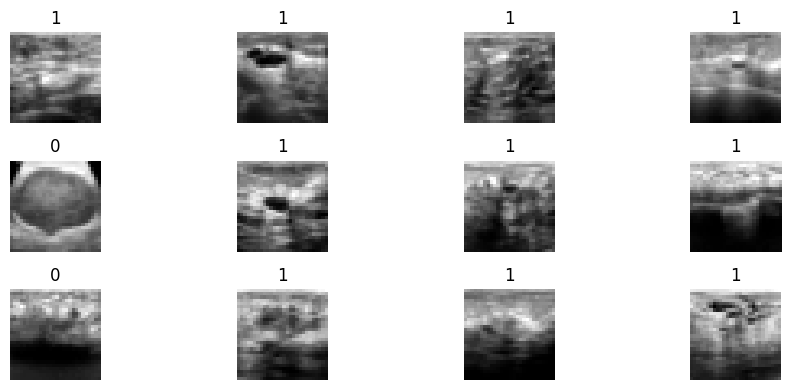

In [4]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


### 3.2. Revisar balance de clases

En datasets médicos pequeños es común que haya desbalance de clases, lo cual afecta cómo debemos interpretar el accuracy. Lo revisamos antes de entrenar.


In [5]:
import numpy as np

labels_train = np.array([int(train_dataset[i][1].item()) for i in range(len(train_dataset))])
unique, counts = np.unique(labels_train, return_counts=True)
dict(zip(unique.tolist(), counts.tolist()))


{0: 147, 1: 399}

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe. Usamos un `batch_size` más pequeño que en el notebook original porque el dataset es mucho más chico.


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [81]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([64, 1, 28, 28]), torch.Size([64, 1]))

## 5. Modelo 1: CNN entrenada desde cero (con regularización)

Construimos una CNN básica, pero a diferencia del notebook original **agregamos BatchNorm y Dropout** (ejercicio sugerido 1), porque con solo ~546 imágenes de entrenamiento una CNN simple memoriza el dataset muy rápido si no se regulariza.

Patrón de cada bloque: `Conv2D → BatchNorm → ReLU → MaxPool`, y `Dropout` antes del clasificador final.


In [82]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout_p=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance, como en este dataset)

Aquí implementamos un loop de entrenamiento estándar y una función de evaluación.


In [83]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    running_loss = 0.0
    criterion_eval = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        loss = criterion_eval(logits, y)
        running_loss += loss.item() * x.size(0)

        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)

    val_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return acc, auc, all_labels, all_preds, all_probs, val_loss


### 5.2. Entrenar el modelo desde cero (con weight decay, scheduler y early stopping)

Además de BatchNorm y Dropout en la arquitectura, agregamos tres mejoras más (ejercicio sugerido 2) pensadas para un dataset pequeño:

- **Weight decay** en el optimizador (regularización L2 sobre los pesos).
- **Scheduler** (`ReduceLROnPlateau`) que baja el learning rate si la validación deja de mejorar.
- **Early stopping**: nos quedamos con los pesos de la época donde el ROC-AUC de validación fue mejor, en vez de simplemente usar la última época — así evitamos quedarnos con un modelo ya sobreajustado.


In [84]:
import copy

criterion = nn.CrossEntropyLoss()
# Opción con Learning Rate más bajo:
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=2e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4)

epochs = 50
patience_es = 50
best_auc = -1
best_state = None
epochs_no_improve = 0

history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_scratch, val_loader)
    scheduler.step(val_auc)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_state = copy.deepcopy(model_scratch.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience_es:
        print(f"Early stopping en la época {epoch} (mejor val_auc={best_auc:.4f})")
        break

model_scratch.load_state_dict(best_state)


Epoch 01 | train_loss=0.8509 | val_loss=0.7501 | val_acc=0.2692 | val_auc=0.5581
Epoch 02 | train_loss=0.7781 | val_loss=0.8556 | val_acc=0.2692 | val_auc=0.5781
Epoch 03 | train_loss=0.7428 | val_loss=0.9835 | val_acc=0.2692 | val_auc=0.6074
Epoch 04 | train_loss=0.7029 | val_loss=1.0149 | val_acc=0.2692 | val_auc=0.6784
Epoch 05 | train_loss=0.6530 | val_loss=0.9431 | val_acc=0.2692 | val_auc=0.7811
Epoch 06 | train_loss=0.6283 | val_loss=0.8063 | val_acc=0.2949 | val_auc=0.8079
Epoch 07 | train_loss=0.6075 | val_loss=0.6737 | val_acc=0.5641 | val_auc=0.8170
Epoch 08 | train_loss=0.5900 | val_loss=0.5888 | val_acc=0.7179 | val_auc=0.8338
Epoch 09 | train_loss=0.5717 | val_loss=0.5363 | val_acc=0.7564 | val_auc=0.8446
Epoch 10 | train_loss=0.5488 | val_loss=0.4900 | val_acc=0.7821 | val_auc=0.8187
Epoch 11 | train_loss=0.5370 | val_loss=0.4835 | val_acc=0.7949 | val_auc=0.8179
Epoch 12 | train_loss=0.5290 | val_loss=0.4783 | val_acc=0.8077 | val_auc=0.8321
Epoch 13 | train_loss=0.5177

<All keys matched successfully>

### 5.3. Curvas de entrenamiento

Visualizamos **pérdida de entrenamiento vs. validación** (no solo la de entrenamiento como en el notebook original) para detectar sobreajuste directamente: si la pérdida de entrenamiento sigue bajando mientras la de validación sube, es la señal clásica de overfitting.


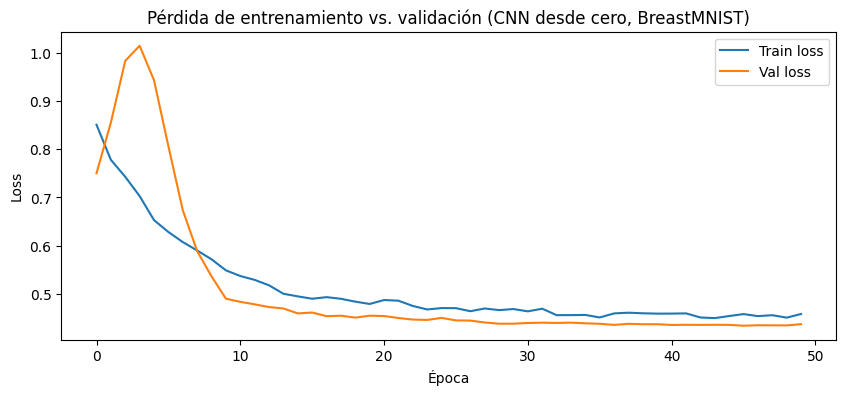

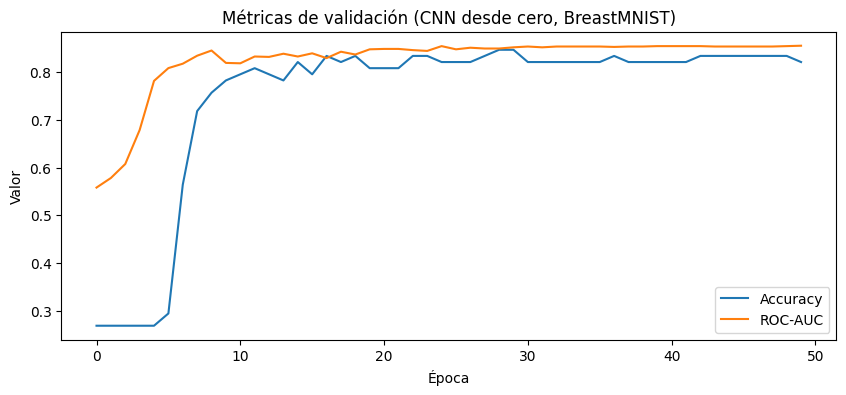

In [85]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train loss")
plt.plot(history_scratch["val_loss"], label="Val loss")
plt.title("Pérdida de entrenamiento vs. validación (CNN desde cero, BreastMNIST)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero, BreastMNIST)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización real.


In [12]:
test_acc, test_auc, y_true, y_pred, y_prob, test_loss = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8397
Test ROC-AUC:  0.8580

              precision    recall  f1-score   support

           0     0.7931    0.5476    0.6479        42
           1     0.8504    0.9474    0.8963       114

    accuracy                         0.8397       156
   macro avg     0.8217    0.7475    0.7721       156
weighted avg     0.8350    0.8397    0.8294       156



array([[ 23,  19],
       [  6, 108]])

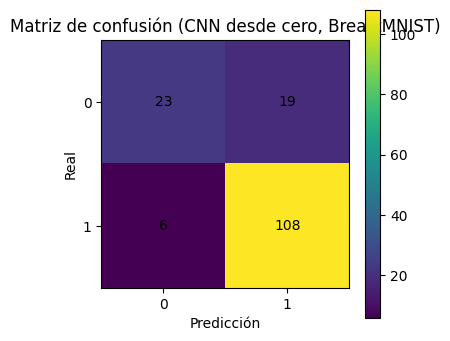

In [13]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero, BreastMNIST)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

Con solo ~546 imágenes de entrenamiento, el aumento de datos es especialmente valioso en BreastMNIST (ejercicio sugerido 3). En ecografías hay que tener cuidado:
- Rotaciones pequeñas y traslaciones suaves son razonables (el paciente puede estar ligeramente distinto en cada toma).
- Flips horizontales suelen ser aceptables en ecografía de mama (no hay una orientación anatómica fija como en una radiografía de tórax).
- Evitamos distorsiones fuertes que puedan alterar estructuras clínicamente relevantes.

Entrenamos un modelo con el mismo diseño (misma arquitectura regularizada) para comparar contra el modelo sin aumento.


In [14]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [15]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

epochs = 25
patience_es = 6
best_auc_aug = -1
best_state_aug = None
epochs_no_improve = 0

history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_aug, val_loader)
    scheduler.step(val_auc)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_auc_aug:
        best_auc_aug = val_auc
        best_state_aug = copy.deepcopy(model_aug.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience_es:
        print(f"Early stopping en la época {epoch} (mejor val_auc={best_auc_aug:.4f})")
        break

model_aug.load_state_dict(best_state_aug)


Epoch 01 | train_loss=0.5906 | val_loss=0.6387 | val_acc=0.7308 | val_auc=0.6825
Epoch 02 | train_loss=0.5177 | val_loss=0.6151 | val_acc=0.7051 | val_auc=0.7444
Epoch 03 | train_loss=0.4920 | val_loss=0.7173 | val_acc=0.7308 | val_auc=0.7293
Epoch 04 | train_loss=0.4825 | val_loss=0.4690 | val_acc=0.7692 | val_auc=0.8246
Epoch 05 | train_loss=0.4648 | val_loss=0.4358 | val_acc=0.8333 | val_auc=0.8262
Epoch 06 | train_loss=0.4589 | val_loss=0.4367 | val_acc=0.8333 | val_auc=0.8722
Epoch 07 | train_loss=0.4688 | val_loss=0.6312 | val_acc=0.7436 | val_auc=0.7828
Epoch 08 | train_loss=0.4549 | val_loss=0.4238 | val_acc=0.8590 | val_auc=0.8429
Epoch 09 | train_loss=0.4616 | val_loss=0.4197 | val_acc=0.8333 | val_auc=0.8505
Epoch 10 | train_loss=0.4195 | val_loss=0.3861 | val_acc=0.8333 | val_auc=0.8805
Epoch 11 | train_loss=0.4158 | val_loss=0.3792 | val_acc=0.8462 | val_auc=0.8839
Epoch 12 | train_loss=0.4245 | val_loss=0.3817 | val_acc=0.8718 | val_auc=0.8839
Epoch 13 | train_loss=0.4411

<All keys matched successfully>

### 6.1. Comparación rápida


In [16]:
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8397 | test_auc=0.8580
Con augmentation  | test_acc=0.8526 | test_auc=0.8638


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (ImageNet) y adaptarlo a nuestra tarea. Es especialmente valioso aquí porque **BreastMNIST solo tiene 780 imágenes** — entrenar una red profunda desde cero con tan pocos datos es mucho más propenso a overfitting que aprovechar características ya aprendidas.

Ventajas:
- Converge más rápido.
- Suele mejorar el rendimiento con pocos datos, que es exactamente nuestro caso.

Desafíos en imágenes médicas:
- Las ecografías son en escala de grises (ImageNet es en color).
- El dominio (ultrasonido) es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1. Convertir la imagen a 3 canales.
2. Redimensionar a un tamaño típico de ResNet.
3. Entrenar un clasificador encima, con congelamiento inicial del backbone.


In [17]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia (más conservadora que en el notebook original, justamente porque el dataset es pequeño):
- Congelar el backbone al inicio y agregar **Dropout** antes de la capa final.
- Entrenar solo la última capa.
- Luego, descongelar únicamente `layer4` para fine-tuning con un learning rate bajo.


In [18]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, num_classes)
)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

epochs = 10
best_auc_tl1 = -1
best_state_tl1 = None

history_tl_stage1 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl)
    scheduler.step(val_auc)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_auc_tl1:
        best_auc_tl1 = val_auc
        best_state_tl1 = copy.deepcopy(resnet.state_dict())

resnet.load_state_dict(best_state_tl1)


Stage1 Epoch 01 | train_loss=0.6164 | val_loss=0.6094 | val_acc=0.7308 | val_auc=0.6600
Stage1 Epoch 02 | train_loss=0.5976 | val_loss=0.5775 | val_acc=0.6795 | val_auc=0.6859
Stage1 Epoch 03 | train_loss=0.6074 | val_loss=0.5192 | val_acc=0.7692 | val_auc=0.7009
Stage1 Epoch 04 | train_loss=0.5970 | val_loss=0.5043 | val_acc=0.7692 | val_auc=0.7452
Stage1 Epoch 05 | train_loss=0.5977 | val_loss=0.5229 | val_acc=0.7692 | val_auc=0.7661
Stage1 Epoch 06 | train_loss=0.5704 | val_loss=0.4810 | val_acc=0.8333 | val_auc=0.7552
Stage1 Epoch 07 | train_loss=0.5277 | val_loss=0.4778 | val_acc=0.8077 | val_auc=0.7627
Stage1 Epoch 08 | train_loss=0.5291 | val_loss=0.4838 | val_acc=0.7692 | val_auc=0.7544
Stage1 Epoch 09 | train_loss=0.5163 | val_loss=0.4779 | val_acc=0.7949 | val_auc=0.7577
Stage1 Epoch 10 | train_loss=0.5008 | val_loss=0.4855 | val_acc=0.7692 | val_auc=0.7494


<All keys matched successfully>

### 7.2. Fine-tuning (descongelar capas)

Descongelamos solo `layer4` (y la nueva `fc`), usando un learning rate más bajo que en la etapa 1 para no destruir lo ya aprendido en ImageNet — esto es clave con pocos datos, ya que descongelar todo el backbone con solo ~546 imágenes llevaría a overfitting casi de inmediato.


In [20]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [21]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

epochs = 10
patience_es = 4
best_auc_tl2 = -1
best_state_tl2 = None
epochs_no_improve = 0

history_tl_stage2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl)
    scheduler.step(val_auc)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_auc_tl2:
        best_auc_tl2 = val_auc
        best_state_tl2 = copy.deepcopy(resnet.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience_es:
        print(f"Early stopping en la época {epoch} (mejor val_auc={best_auc_tl2:.4f})")
        break

resnet.load_state_dict(best_state_tl2)


Stage2 Epoch 01 | train_loss=0.5198 | val_loss=0.4300 | val_acc=0.8462 | val_auc=0.8170
Stage2 Epoch 02 | train_loss=0.4106 | val_loss=0.4005 | val_acc=0.8590 | val_auc=0.8538
Stage2 Epoch 03 | train_loss=0.3918 | val_loss=0.3817 | val_acc=0.8718 | val_auc=0.8513
Stage2 Epoch 04 | train_loss=0.3335 | val_loss=0.3572 | val_acc=0.8974 | val_auc=0.8764
Stage2 Epoch 05 | train_loss=0.2997 | val_loss=0.3775 | val_acc=0.8590 | val_auc=0.8663
Stage2 Epoch 06 | train_loss=0.2774 | val_loss=0.3847 | val_acc=0.8846 | val_auc=0.8830
Stage2 Epoch 07 | train_loss=0.2479 | val_loss=0.4298 | val_acc=0.8590 | val_auc=0.8997
Stage2 Epoch 08 | train_loss=0.2337 | val_loss=0.4938 | val_acc=0.8718 | val_auc=0.8555
Stage2 Epoch 09 | train_loss=0.2200 | val_loss=0.4355 | val_acc=0.8462 | val_auc=0.8530
Stage2 Epoch 10 | train_loss=0.2026 | val_loss=0.4069 | val_acc=0.8846 | val_auc=0.8655


<All keys matched successfully>

### 7.3. Evaluación en test del modelo con transfer learning


In [22]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl, _ = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8013 | test_auc=0.9054

              precision    recall  f1-score   support

           0     0.8235    0.3333    0.4746        42
           1     0.7986    0.9737    0.8775       114

    accuracy                         0.8013       156
   macro avg     0.8110    0.6535    0.6760       156
weighted avg     0.8053    0.8013    0.7690       156



array([[ 14,  28],
       [  3, 111]])

### 7.4. Comparación global (resumen)


In [23]:
print("Resumen de resultados en test (BreastMNIST)")
print(f"CNN desde cero (sin aug)   | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)   | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test (BreastMNIST)
CNN desde cero (sin aug)   | acc=0.8397 | auc=0.8580
CNN desde cero (con aug)   | acc=0.8526 | auc=0.8638
Transfer learning (ResNet) | acc=0.8013 | auc=0.9054


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es tan importante como el resultado mismo.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando las regiones que más influyeron en la predicción. Aquí implementamos una versión simplificada para ResNet18.


In [24]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    model.zero_grad()
    logits[0, target_class].backward()

    acts = activations["value"][0]
    grads = gradients["value"][0]
    weights = grads.mean(dim=(1, 2))

    cam = torch.zeros(acts.shape[1:], dtype=torch.float32, device=device)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = cam.detach().cpu().numpy()

    handle_fwd.remove()
    handle_bwd.remove()

    return cam, target_class


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


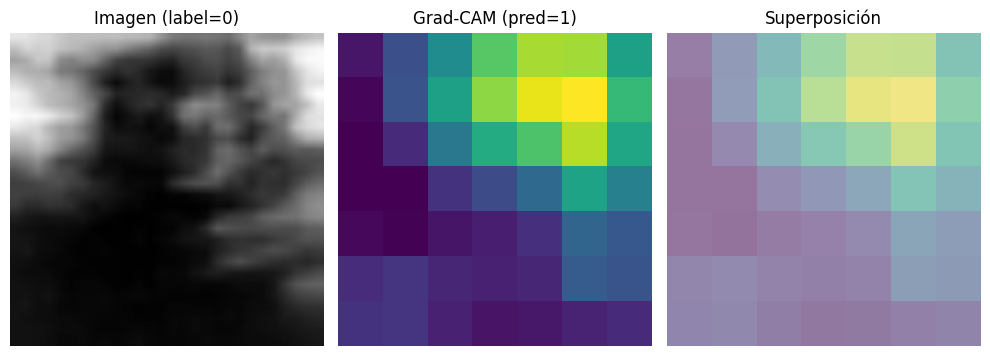

In [25]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Curvas ROC y calibración de probabilidades

Además del ROC-AUC (un solo número resumen), es importante **visualizar la curva ROC completa** y revisar si las probabilidades que da el modelo están **bien calibradas** : que una probabilidad de 0.8 realmente signifique "80% de las veces es positivo", y no solo un número arbitrario que separa bien las clases pero está mal calibrado.


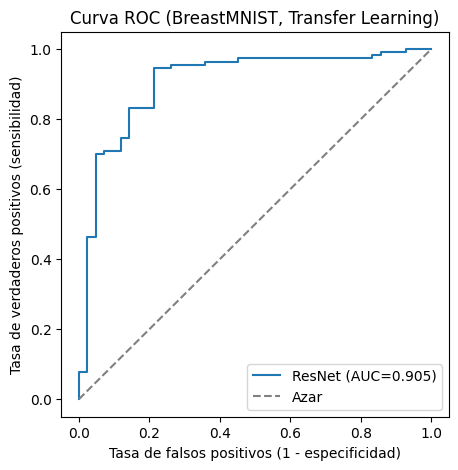

In [26]:
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

fpr, tpr, _ = roc_curve(y_true_tl, y_prob_tl)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ResNet (AUC={test_auc_tl:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.title("Curva ROC (BreastMNIST, Transfer Learning)")
plt.legend()
plt.show()


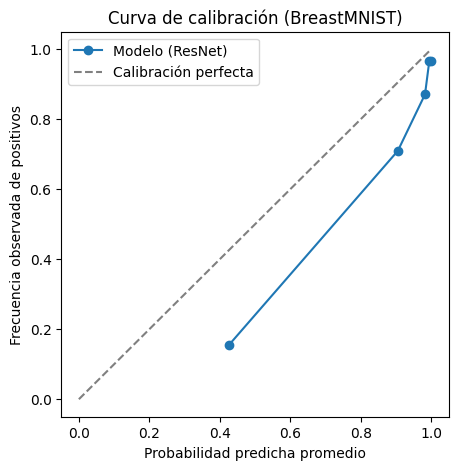

In [27]:
prob_true, prob_pred = calibration_curve(y_true_tl, y_prob_tl, n_bins=5, strategy="quantile")

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo (ResNet)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha promedio")
plt.ylabel("Frecuencia observada de positivos")
plt.title("Curva de calibración (BreastMNIST)")
plt.legend()
plt.show()


**Cómo interpretar la curva de calibración:** si los puntos caen cerca de la diagonal, el modelo está bien calibrado (sus probabilidades son confiables). Si los puntos están sistemáticamente por debajo o por encima de la diagonal, el modelo está **sub-confiado** o **sobre-confiado**, respectivamente — algo común en modelos entrenados con pocos datos, y una razón más para no confiar ciegamente en el accuracy o en probabilidades "crudas" en un contexto clínico.


## 10. Buenas prácticas (especialmente en salud)

1. **Separación estricta** de train/val/test para evitar data leakage — usamos siempre el split oficial de MedMNIST.

2. Reportar métricas más allá del accuracy:
   - **Recall (sensibilidad)**: qué tanto detectas casos malignos reales.
   - **Especificidad**: qué tanto evitas falsos positivos.
   - **ROC-AUC**: separación global entre clases.
   - **Calibración**: qué tan confiables son las probabilidades, no solo la clase final.

3. Cuidado con sesgos:
   - Diferencias por equipo de ultrasonido, hospital, población de pacientes.
   - Etiquetas ruidosas o revisadas por un solo especialista.

4. Con datasets pequeños (como BreastMNIST, 780 imágenes) el overfitting es el riesgo #1:
   - Arquitectura regularizada (BatchNorm + Dropout).
   - Weight decay y scheduler de learning rate.
   - Early stopping basado en la métrica de validación (no en la última época).
   - Data augmentation moderado y clínicamente razonable.
   - Preferir transfer learning sobre entrenar una red profunda desde cero.

5. Validación externa:
   - Probar en datos de otra fuente/hospital es clave antes de cualquier uso real.

6. Interpretabilidad:
   - Grad-CAM es útil para inspeccionar el modelo, pero **no prueba causalidad** ni reemplaza el criterio médico.

7. Reproducibilidad:
   - Fijar semillas (seeds), registrar versiones de librerías y guardar los pesos del mejor modelo (no del último).


## 11. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones, sin tener que reentrenar desde cero.


In [28]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch_breastmnist.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug_breastmnist.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer_breastmnist.pth")

["models/cnn_scratch_breastmnist.pth", "models/cnn_aug_breastmnist.pth", "models/resnet_transfer_breastmnist.pth"]


['models/cnn_scratch_breastmnist.pth',
 'models/cnn_aug_breastmnist.pth',
 'models/resnet_transfer_breastmnist.pth']

## 12. Conclusiones: cómo se evitó el overfitting en este notebook

Con un dataset de solo 780 imágenes, el mayor riesgo no era "que el modelo no aprenda", sino que **memorice** el set de entrenamiento. Las decisiones tomadas en este notebook, todas apuntando a lo mismo, fueron:

| Técnica | Dónde se aplicó | Qué evita |
|---|---|---|
| BatchNorm | Arquitectura `SimpleCNN` | Activaciones inestables, ligera regularización |
| Dropout | `SimpleCNN` y capa `fc` de ResNet | Dependencia de neuronas específicas |
| Weight decay (L2) | Todos los optimizadores Adam | Pesos demasiado grandes / complejidad excesiva |
| Data augmentation moderado | Sección 6 y transfer learning | Memorización de imágenes exactas |
| Early stopping por `val_auc` | Todos los entrenamientos | Quedarse con un modelo ya sobreajustado |
| Fine-tuning parcial (solo `layer4`) | Sección 7.2 | Destruir el conocimiento preentrenado con pocos datos |
| Curvas train vs. val loss | Sección 5.3 | Detectar overfitting visualmente en tiempo real |
| ROC-AUC + calibración (no solo accuracy) | Secciones 5–9 | Confiar en una métrica engañosa por desbalance de clases |

En conjunto, esto convierte al notebook en una plantilla razonable para cualquier dataset médico pequeño dentro de `medmnist` (por ejemplo, si luego se quisiera probar con `dermamnist` u otro), no solo para BreastMNIST.
